In [1]:
import cv2
import os
import numpy as np

print(cv2.__version__)

5.0.0


In [2]:
print(hasattr(cv2, "face"))

True


In [3]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

print("LBPH Recognizer Created Successfully!")

LBPH Recognizer Created Successfully!


In [4]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=20, resize=0.5)

print("Images :", faces.images.shape)
print("Labels :", faces.target.shape)
print("Persons:", len(faces.target_names))

Images : (3023, 62, 47)
Labels : (3023,)
Persons: 62


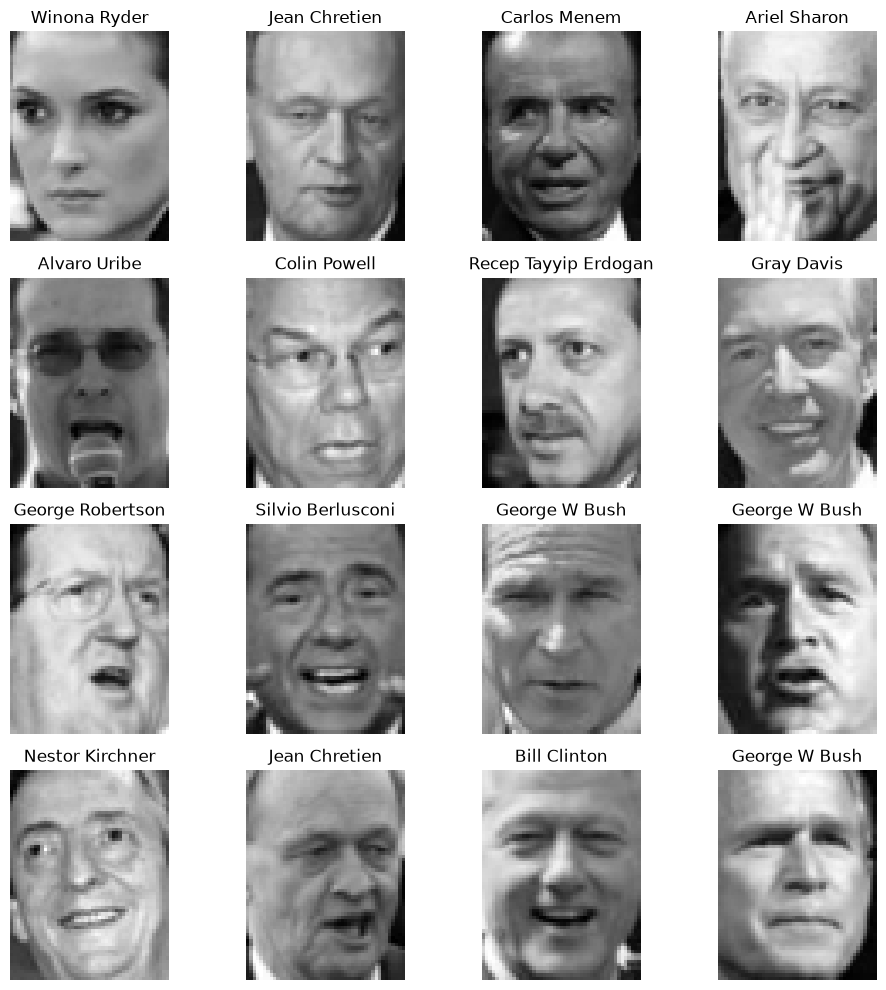

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(faces.images[i], cmap="gray")
    plt.title(faces.target_names[faces.target[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
print(hasattr(cv2, "face"))

True


In [7]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

print("LBPH Recognizer Created Successfully!")

LBPH Recognizer Created Successfully!


In [8]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(
    min_faces_per_person=20,
    resize=0.5
)

print("Images :", faces.images.shape)
print("Labels :", faces.target.shape)
print("Persons:", len(faces.target_names))

Images : (3023, 62, 47)
Labels : (3023,)
Persons: 62


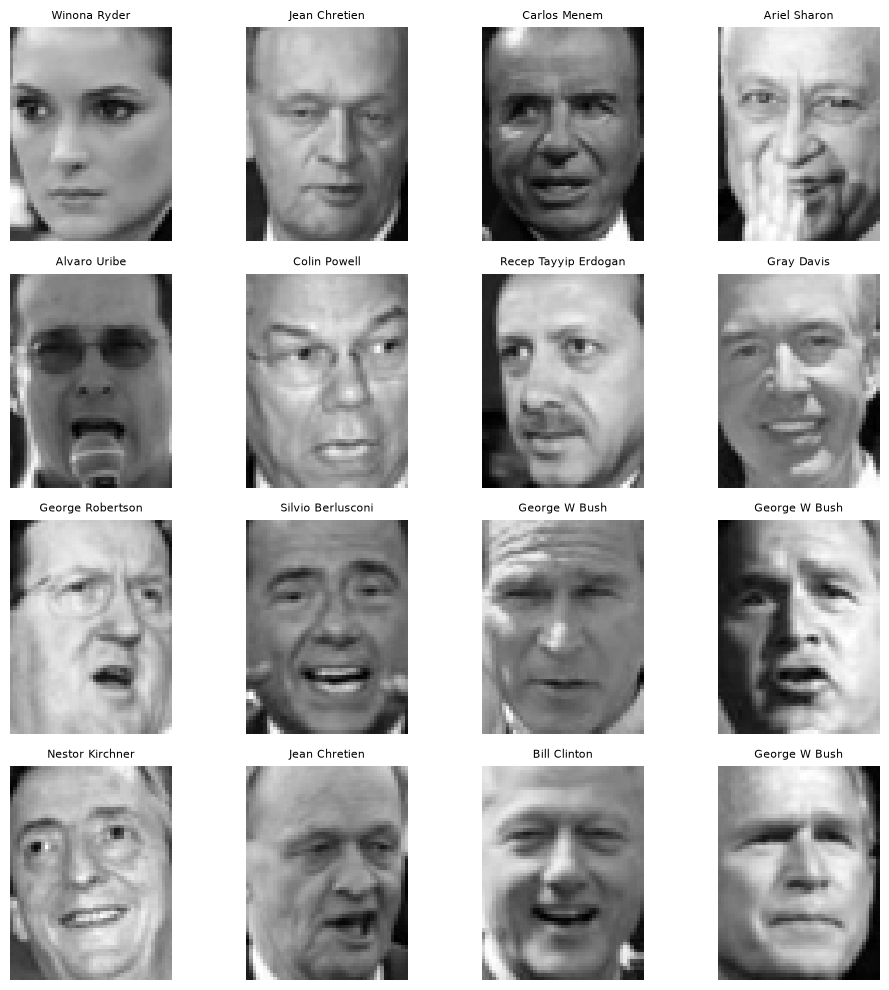

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces.images[i], cmap="gray")
    plt.title(faces.target_names[faces.target[i]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
print("Image Shape:", faces.images.shape)
print("Target Shape:", faces.target.shape)
print("Target Names:")

for i, name in enumerate(faces.target_names):
    print(i, ":", name)

Image Shape: (3023, 62, 47)
Target Shape: (3023,)
Target Names:
0 : Alejandro Toledo
1 : Alvaro Uribe
2 : Amelie Mauresmo
3 : Andre Agassi
4 : Angelina Jolie
5 : Ariel Sharon
6 : Arnold Schwarzenegger
7 : Atal Bihari Vajpayee
8 : Bill Clinton
9 : Carlos Menem
10 : Colin Powell
11 : David Beckham
12 : Donald Rumsfeld
13 : George Robertson
14 : George W Bush
15 : Gerhard Schroeder
16 : Gloria Macapagal Arroyo
17 : Gray Davis
18 : Guillermo Coria
19 : Hamid Karzai
20 : Hans Blix
21 : Hugo Chavez
22 : Igor Ivanov
23 : Jack Straw
24 : Jacques Chirac
25 : Jean Chretien
26 : Jennifer Aniston
27 : Jennifer Capriati
28 : Jennifer Lopez
29 : Jeremy Greenstock
30 : Jiang Zemin
31 : John Ashcroft
32 : John Negroponte
33 : Jose Maria Aznar
34 : Juan Carlos Ferrero
35 : Junichiro Koizumi
36 : Kofi Annan
37 : Laura Bush
38 : Lindsay Davenport
39 : Lleyton Hewitt
40 : Luiz Inacio Lula da Silva
41 : Mahmoud Abbas
42 : Megawati Sukarnoputri
43 : Michael Bloomberg
44 : Naomi Watts
45 : Nestor Kirchner
46

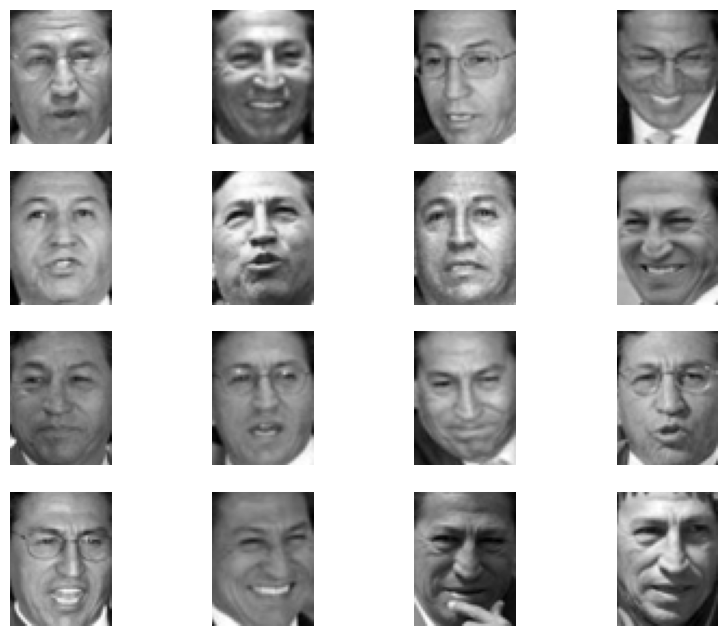

In [11]:
person = 0

plt.figure(figsize=(10,8))

count = 1

for i in range(len(faces.images)):
    if faces.target[i] == person:
        plt.subplot(4,4,count)
        plt.imshow(faces.images[i], cmap="gray")
        plt.axis("off")
        count += 1

        if count > 16:
            break

plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = faces.images
y = faces.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2418, 62, 47)
(605, 62, 47)


In [13]:
X_train = (X_train * 255).astype("uint8")
X_test = (X_test * 255).astype("uint8")

In [14]:
train_images = []

for img in X_train:
    train_images.append(img)

train_labels = np.array(y_train)

In [15]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

In [16]:
print("Image Shape :", faces.images.shape)
print("Target Shape:", faces.target.shape)
print("Number of Persons:", len(faces.target_names))

print("\nPeople in Dataset:\n")

for i, name in enumerate(faces.target_names):
    print(f"{i}: {name}")

Image Shape : (3023, 62, 47)
Target Shape: (3023,)
Number of Persons: 62

People in Dataset:

0: Alejandro Toledo
1: Alvaro Uribe
2: Amelie Mauresmo
3: Andre Agassi
4: Angelina Jolie
5: Ariel Sharon
6: Arnold Schwarzenegger
7: Atal Bihari Vajpayee
8: Bill Clinton
9: Carlos Menem
10: Colin Powell
11: David Beckham
12: Donald Rumsfeld
13: George Robertson
14: George W Bush
15: Gerhard Schroeder
16: Gloria Macapagal Arroyo
17: Gray Davis
18: Guillermo Coria
19: Hamid Karzai
20: Hans Blix
21: Hugo Chavez
22: Igor Ivanov
23: Jack Straw
24: Jacques Chirac
25: Jean Chretien
26: Jennifer Aniston
27: Jennifer Capriati
28: Jennifer Lopez
29: Jeremy Greenstock
30: Jiang Zemin
31: John Ashcroft
32: John Negroponte
33: Jose Maria Aznar
34: Juan Carlos Ferrero
35: Junichiro Koizumi
36: Kofi Annan
37: Laura Bush
38: Lindsay Davenport
39: Lleyton Hewitt
40: Luiz Inacio Lula da Silva
41: Mahmoud Abbas
42: Megawati Sukarnoputri
43: Michael Bloomberg
44: Naomi Watts
45: Nestor Kirchner
46: Paul Bremer
47

In [17]:
unique, counts = np.unique(faces.target, return_counts=True)

for i in range(len(unique)):
    print(f"{faces.target_names[unique[i]]} : {counts[i]}")

Alejandro Toledo : 39
Alvaro Uribe : 35
Amelie Mauresmo : 21
Andre Agassi : 36
Angelina Jolie : 20
Ariel Sharon : 77
Arnold Schwarzenegger : 42
Atal Bihari Vajpayee : 24
Bill Clinton : 29
Carlos Menem : 21
Colin Powell : 236
David Beckham : 31
Donald Rumsfeld : 121
George Robertson : 22
George W Bush : 530
Gerhard Schroeder : 109
Gloria Macapagal Arroyo : 44
Gray Davis : 26
Guillermo Coria : 30
Hamid Karzai : 22
Hans Blix : 39
Hugo Chavez : 71
Igor Ivanov : 20
Jack Straw : 28
Jacques Chirac : 52
Jean Chretien : 55
Jennifer Aniston : 21
Jennifer Capriati : 42
Jennifer Lopez : 21
Jeremy Greenstock : 24
Jiang Zemin : 20
John Ashcroft : 53
John Negroponte : 31
Jose Maria Aznar : 23
Juan Carlos Ferrero : 28
Junichiro Koizumi : 60
Kofi Annan : 32
Laura Bush : 41
Lindsay Davenport : 22
Lleyton Hewitt : 41
Luiz Inacio Lula da Silva : 48
Mahmoud Abbas : 29
Megawati Sukarnoputri : 33
Michael Bloomberg : 20
Naomi Watts : 22
Nestor Kirchner : 37
Paul Bremer : 20
Pete Sampras : 22
Recep Tayyip Erdo

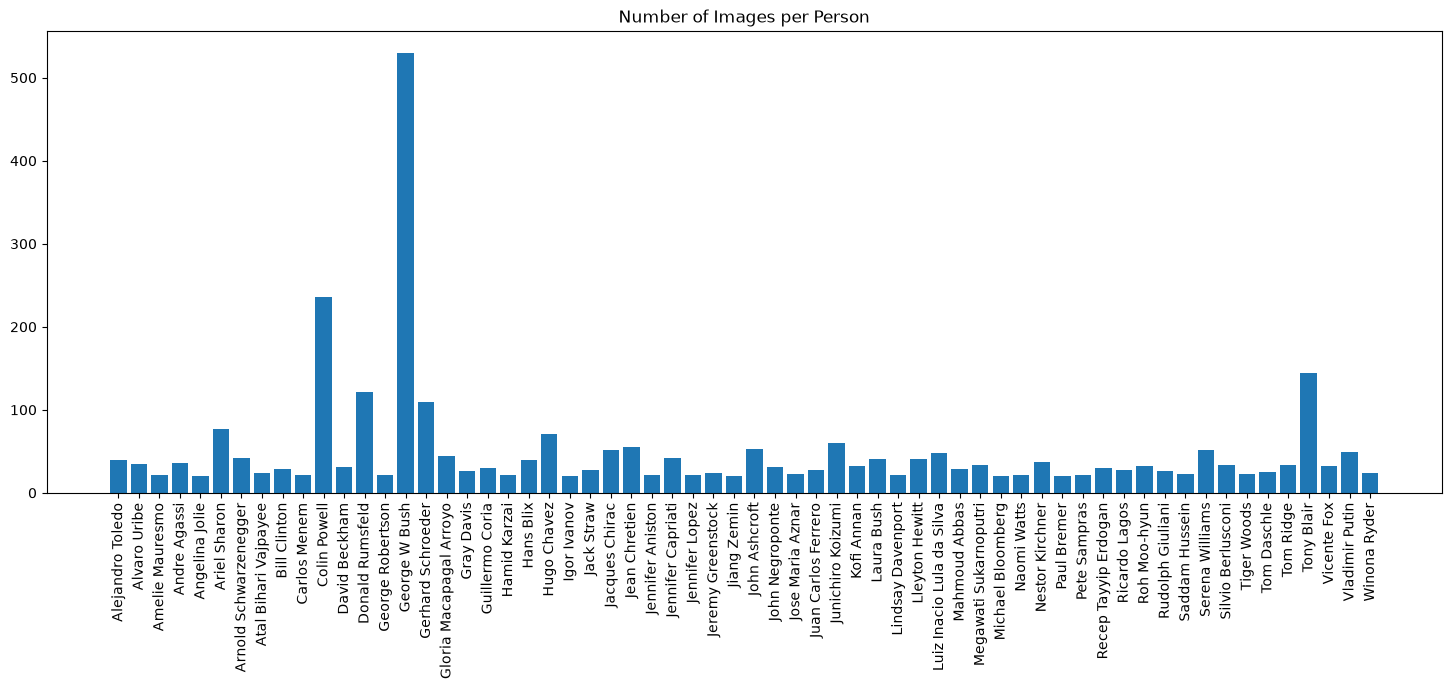

In [18]:
plt.figure(figsize=(18,6))

plt.bar(faces.target_names, counts)

plt.xticks(rotation=90)
plt.title("Number of Images per Person")

plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X = faces.images
y = faces.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (2418, 62, 47)
Testing Images  : (605, 62, 47)


In [20]:
X_train = (X_train * 255).astype(np.uint8)
X_test = (X_test * 255).astype(np.uint8)

print(X_train.dtype)
print(X_train.shape)

uint8
(2418, 62, 47)


In [21]:
recognizer = cv2.face.LBPHFaceRecognizer_create()

print("LBPH Recognizer Created")

LBPH Recognizer Created


In [22]:
recognizer.train(
    list(X_train),
    np.array(y_train)
)

print("Training Completed Successfully")

Training Completed Successfully


In [23]:
recognizer.save("../app/models/face_recognizer.yml")

print("Face Recognition Model Saved Successfully!")

Face Recognition Model Saved Successfully!


In [24]:
import joblib

label_map = {}

for i, name in enumerate(faces.target_names):
    label_map[i] = name

joblib.dump(
    label_map,
    "../app/models/face_labels.pkl"
)

print("Label Map Saved Successfully!")

Label Map Saved Successfully!


In [25]:
test_image = X_test[0]

predicted_label, confidence = recognizer.predict(test_image)

print("Predicted :", label_map[predicted_label])
print("Actual    :", label_map[y_test[0]])
print("Confidence:", confidence)

Predicted : Serena Williams
Actual    : Serena Williams
Confidence: 134.82548149471302


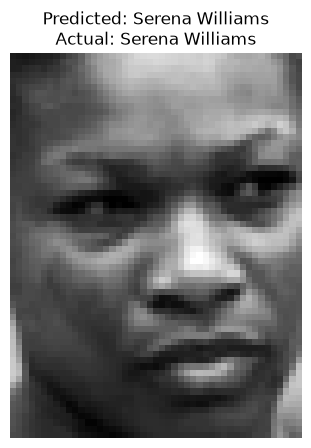

In [26]:
plt.figure(figsize=(5,5))

plt.imshow(test_image, cmap="gray")

plt.title(
    f"Predicted: {label_map[predicted_label]}\n"
    f"Actual: {label_map[y_test[0]]}"
)

plt.axis("off")

plt.show()

In [27]:
correct = 0

for image, true_label in zip(X_test, y_test):

    predicted_label, confidence = recognizer.predict(image)

    if predicted_label == true_label:
        correct += 1

accuracy = correct / len(y_test)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 68.26%


In [28]:
print("="*40)
print("Face Recognition Module Completed")
print("="*40)

print(f"Total Test Images : {len(y_test)}")
print(f"Correct Predictions : {correct}")
print(f"Accuracy : {accuracy*100:.2f}%")

Face Recognition Module Completed
Total Test Images : 605
Correct Predictions : 413
Accuracy : 68.26%


In [29]:
print(X_train.shape)
print(X_train[0].shape)

(2418, 62, 47)
(62, 47)


In [30]:
import matplotlib.pyplot as plt

plt.imsave(
    "../uploads/test_face.png",
    X_test[0],
    cmap="gray"
)

print("Face image saved successfully!")

print("Actual Person:", label_map[y_test[0]])

Face image saved successfully!
Actual Person: Serena Williams
